# Tag 10 — Experten
## LightGBM + Optuna + Ensemble — House Prices

In [7]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path(r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project")
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()
    while PROJECT_DIR.name not in ["Tag_10_Boosting_Project", ""] and PROJECT_DIR.parent != PROJECT_DIR:
        PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "03_experten"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\data\raw
OUTPUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\outputs\03_experten


In [8]:

TRAIN_PATH = DATA_DIR / "train.csv"
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"train.csv not found in: {DATA_DIR}")

df = pd.read_csv(TRAIN_PATH)
target_col = "SalePrice"
X = df.drop(columns=[target_col])
y = df[target_col]
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(1168, 79) (292, 79)


In [9]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)
])

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
print(X_train_pre.shape, X_test_pre.shape)


(1168, 285) (292, 285)


C:\Users\esmae\AppData\Local\Temp\ipykernel_40936\4204357741.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [10]:

try:
    import lightgbm as lgb
    import optuna
    lgb_optuna_available = True
except ModuleNotFoundError as e:
    lgb_optuna_available = False
    print("Missing package:", e)
    print("Install with: pip install lightgbm optuna")

N_TRIALS = 20
# For the original task, you can change this to 50.


In [11]:

from sklearn.model_selection import KFold, cross_val_score

if lgb_optuna_available:
    def objective(trial):
        params = {
            "n_estimators": 500,
            "num_leaves": trial.suggest_int("num_leaves", 20, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "random_state": 42,
            "n_jobs": 1,
            "verbosity": -1
        }
        model = lgb.LGBMRegressor(**params)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train_pre, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
        return -scores.mean()

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS)
    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(OUTPUT_DIR / "expert_optuna_trials.csv", index=False)
else:
    study = None


[I 2026-06-05 13:28:50,618] A new study created in memory with name: no-name-98dae8bf-f063-4450-bf73-563c6cf9f7c7
c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-06-05 13:28:51,177] Trial 0 finished with value: 32668.658125997503 and parameters: {'num_leaves': 45, 'learning_rate': 0.1654903068265992, 'min_child_samples': 81, 'subsample': 0

Best RMSE: 28309.975988416907
Best params: {'num_leaves': 236, 'learning_rate': 0.018056015139000087, 'min_child_samples': 24, 'subsample': 0.9574950951469458, 'colsample_bytree': 0.700981606258547}


In [12]:

if lgb_optuna_available and study is not None:
    best_lgbm = lgb.LGBMRegressor(
        n_estimators=800,
        **study.best_params,
        random_state=42,
        n_jobs=1,
        verbosity=-1
    )
    best_lgbm.fit(X_train_pre, y_train)
    lgb_pred = best_lgbm.predict(X_test_pre)
    lgb_rmse = mean_squared_error(y_test, lgb_pred) ** 0.5
    lgb_r2 = r2_score(y_test, lgb_pred)
    print("LightGBM Test RMSE:", lgb_rmse)
    print("LightGBM Test R2:", lgb_r2)
else:
    lgb_pred, lgb_rmse, lgb_r2 = None, np.nan, np.nan


LightGBM Test RMSE: 28391.22739447717
LightGBM Test R2: 0.8949116672235363


c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,test_rmse
1,XGBoost,25431.573447
3,Averaging_Ensemble,25959.549440
2,CatBoost,26190.991814
0,LightGBM_Optuna,28391.227394


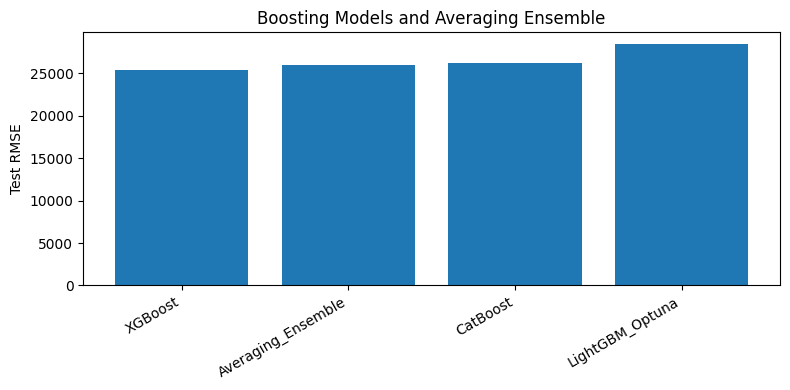

In [13]:

try:
    from xgboost import XGBRegressor
    xgb_model = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.05, objective="reg:squarederror", random_state=42, n_jobs=1)
    xgb_model.fit(X_train_pre, y_train)
    xgb_pred = xgb_model.predict(X_test_pre)
    xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
except ModuleNotFoundError:
    xgb_pred, xgb_rmse = None, np.nan

try:
    from catboost import CatBoostRegressor
    cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE", random_seed=42, verbose=False)
    cat_model.fit(X_train_pre, y_train)
    cat_pred = cat_model.predict(X_test_pre)
    cat_rmse = mean_squared_error(y_test, cat_pred) ** 0.5
except ModuleNotFoundError:
    cat_pred, cat_rmse = None, np.nan

results = []
if lgb_pred is not None: results.append({"model":"LightGBM_Optuna", "test_rmse":lgb_rmse})
if xgb_pred is not None: results.append({"model":"XGBoost", "test_rmse":xgb_rmse})
if cat_pred is not None: results.append({"model":"CatBoost", "test_rmse":cat_rmse})

preds = [p for p in [lgb_pred, xgb_pred, cat_pred] if p is not None]
if len(preds) >= 2:
    ensemble_pred = np.mean(preds, axis=0)
    ensemble_rmse = mean_squared_error(y_test, ensemble_pred) ** 0.5
    results.append({"model":"Averaging_Ensemble", "test_rmse":ensemble_rmse})

results_df = pd.DataFrame(results).sort_values("test_rmse")
display(results_df)
results_df.to_csv(OUTPUT_DIR / "expert_boosting_ensemble_comparison.csv", index=False)

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_rmse"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test RMSE")
plt.title("Boosting Models and Averaging Ensemble")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "expert_boosting_ensemble_rmse.png", dpi=200)
plt.show()


C:\Users\esmae\AppData\Local\Temp\ipykernel_40936\3017225641.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = ovm.plot_optimization_history(study)


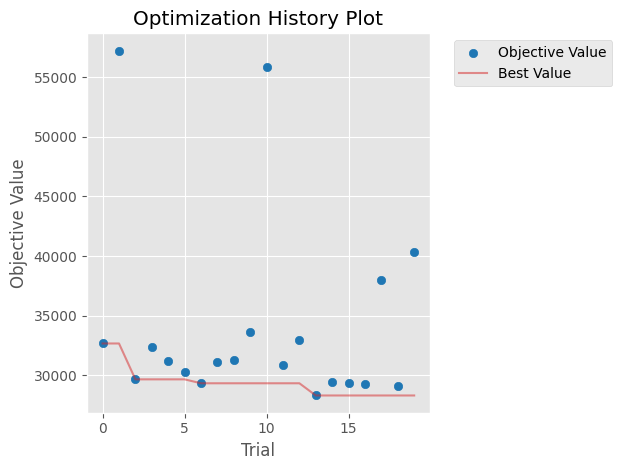

C:\Users\esmae\AppData\Local\Temp\ipykernel_40936\3017225641.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = ovm.plot_param_importances(study)


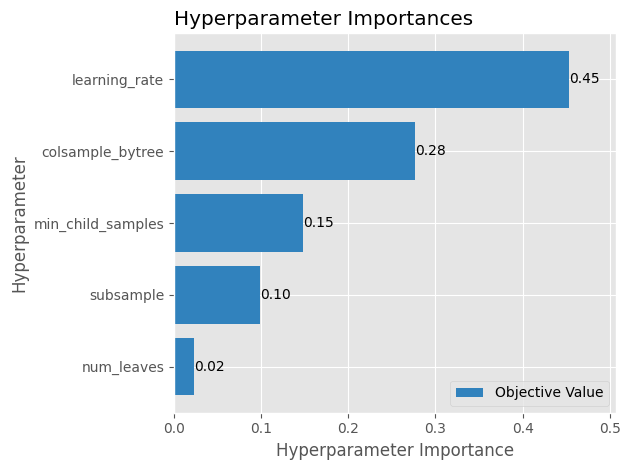

In [14]:

if lgb_optuna_available and study is not None:
    try:
        import optuna.visualization.matplotlib as ovm
        ax = ovm.plot_optimization_history(study)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "expert_optuna_optimization_history.png", dpi=200)
        plt.show()
        ax = ovm.plot_param_importances(study)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "expert_optuna_param_importances.png", dpi=200)
        plt.show()
    except Exception as e:
        print("Optuna plotting skipped:", repr(e))
